In [1]:
!pip install mediapipe opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [2]:
import cv2
import mediapipe as mp
import numpy as np

In [3]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=1,
    min_detection_confidence=0.5
)

mp_draw = mp.solutions.drawing_utils

AttributeError: module 'mediapipe' has no attribute 'solutions'

In [4]:
import mediapipe as mp

print(mp)
print(mp.__file__)
print(dir(mp)[:20])

<module 'mediapipe' from '/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py'>
/usr/local/lib/python3.12/dist-packages/mediapipe/__init__.py
['Image', 'ImageFormat', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'tasks']


In [5]:
!pip show mediapipe

Name: mediapipe
Version: 0.10.35
Summary: MediaPipe is the simplest way for researchers and developers to build world-class ML solutions and applications for mobile, edge, cloud and the web.
Home-page: https://github.com/google/mediapipe
Author: The MediaPipe Authors
Author-email: mediapipe@google.com
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, certifi, flatbuffers, matplotlib, numpy, opencv-contrib-python, sounddevice
Required-by: 


In [6]:
import os
print(os.listdir())

['.config', 'sample_data']


In [7]:
import sys
!pip uninstall -y mediapipe
!pip install mediapipe==0.10.21
!pip install --upgrade protobuf


Found existing installation: mediapipe 0.10.35
Uninstalling mediapipe-0.10.35:
  Successfully uninstalled mediapipe-0.10.35
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import google.protobuf
print(google.protobuf.__version__)

5.29.5


In [2]:
import mediapipe as mp

print(mp.__version__)
print(hasattr(mp, "solutions"))

0.10.21
True


In [3]:
import sys
print(sys.version)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]


In [4]:
import sys

print("Python:", sys.version)

try:
    import mediapipe as mp
    print("MediaPipe:", mp.__version__)
    print("Has solutions:", hasattr(mp, "solutions"))
except Exception as e:
    print("ERROR:", e)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
MediaPipe: 0.10.21
Has solutions: True


In [5]:
import cv2
import mediapipe as mp
import numpy as np
import matplotlib.pyplot as plt

In [6]:
mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=2,
    min_detection_confidence=0.5
)

In [7]:
from google.colab import files

uploaded = files.upload()

Saving ChatGPT Image Jun 11, 2026, 04_06_31 PM.png to ChatGPT Image Jun 11, 2026, 04_06_31 PM.png


In [8]:
image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = hands.process(img_rgb)

In [9]:
if results.multi_hand_landmarks:
    print("Hand Detected!")

    for hand_landmarks in results.multi_hand_landmarks:
        mp_draw.draw_landmarks(
            img,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )
else:
    print("No Hand Detected!")

Hand Detected!


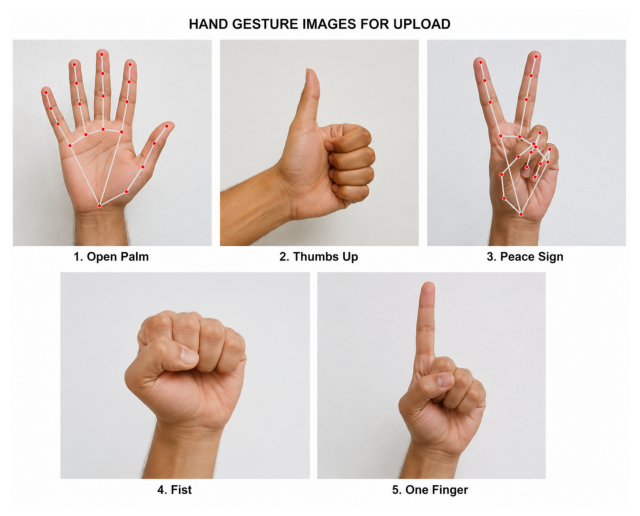

In [10]:
plt.figure(figsize=(8,8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [11]:
if results.multi_hand_landmarks:

    hand = results.multi_hand_landmarks[0]

    tips = [4, 8, 12, 16, 20]

    fingers = []

    # Thumb
    if hand.landmark[4].x < hand.landmark[3].x:
        fingers.append(1)
    else:
        fingers.append(0)

    # Other Fingers
    for tip in tips[1:]:
        if hand.landmark[tip].y < hand.landmark[tip-2].y:
            fingers.append(1)
        else:
            fingers.append(0)

    total = sum(fingers)

    print("Fingers Up:", total)

Fingers Up: 4


In [12]:
gesture = "Unknown"

if total == 0:
    gesture = "Fist ✊"

elif total == 5:
    gesture = "Open Palm ✋"

elif total == 1:
    gesture = "One Finger ☝️"

elif total == 2:
    gesture = "Peace Sign ✌️"

print("Gesture:", gesture)

Gesture: Unknown


Saved: output_image.png


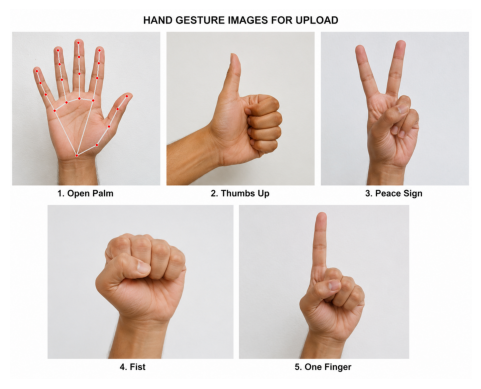

In [13]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

mp_hands = mp.solutions.hands
mp_draw = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=True,
    max_num_hands=1,
    min_detection_confidence=0.5
)

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

results = hands.process(img_rgb)

if results.multi_hand_landmarks:

    for hand_landmarks in results.multi_hand_landmarks:

        mp_draw.draw_landmarks(
            img,
            hand_landmarks,
            mp_hands.HAND_CONNECTIONS
        )

    output_file = "output_image.png"

    cv2.imwrite(output_file, img)

    print(f"Saved: {output_file}")

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.show()

else:
    print("No hand detected")

In [14]:
cv2.imwrite("open_palm_result.png", img)

True

In [15]:
cv2.imwrite("fist_result.png", img)

True

In [16]:
cv2.imwrite("peace_sign_result.png", img)

True

In [17]:
cv2.imwrite("one_finger_result.png", img)

True

In [18]:
from google.colab import files

files.download("open_palm_result.png")
files.download("fist_result.png")
files.download("peace_sign_result.png")
files.download("one_finger_result.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [19]:
cv2.putText(
    img,
    "OPEN PALM",
    (20, 50),
    cv2.FONT_HERSHEY_SIMPLEX,
    1,
    (0, 255, 0),
    2
)

array([[[255, 254, 254],
        [255, 254, 254],
        [254, 253, 254],
        ...,
        [254, 255, 255],
        [255, 255, 255],
        [254, 255, 254]],

       [[254, 253, 253],
        [255, 254, 254],
        [254, 254, 253],
        ...,
        [254, 254, 254],
        [255, 255, 255],
        [254, 254, 255]],

       [[254, 253, 253],
        [254, 254, 254],
        [254, 254, 253],
        ...,
        [255, 255, 255],
        [255, 254, 255],
        [254, 254, 254]],

       ...,

       [[254, 255, 254],
        [255, 255, 255],
        [255, 254, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[255, 255, 255],
        [255, 255, 255],
        [255, 255, 255],
        ...,
        [254, 254, 254],
        [254, 254, 254],
        [254, 254, 254]],

       [[254, 254, 254],
        [254, 254, 254],
        [255, 255, 255],
        ...,
        [254, 253, 254],
        [254, 254, 254],
        [253, 253, 253]]